In [13]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
#include("src/new_funcs.jl")

  Activating project at `~/Desktop/cosmo/blast_code`
  No Changes to `~/Desktop/cosmo/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/blast_code/Manifest.toml`


Main.blast_tutorials

In [14]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LinearAlgebra

In [15]:
using Revise
using .Blast
using .blast_tutorials

In [39]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy")
println("z")
println(z_b)
χ_b = npzread("blast_code/data/background/chi.npy")
println("chi(z)")
println(χ_b)
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b);

z
[0.0, 0.09775171065493646, 0.19550342130987292, 0.29325513196480935, 0.39100684261974583, 0.4887585532746823, 0.5865102639296187, 0.6842619745845552, 0.7820136852394917, 0.8797653958944281, 0.9775171065493646, 1.075268817204301, 1.1730205278592374, 1.270772238514174, 1.3685239491691104, 1.466275659824047, 1.5640273704789833, 1.6617790811339197, 1.7595307917888563, 1.8572825024437927, 1.9550342130987293, 2.0527859237536656, 2.150537634408602, 2.2482893450635384, 2.3460410557184748, 2.4437927663734116, 2.541544477028348, 2.6392961876832843, 2.7370478983382207, 2.834799608993157, 2.932551319648094, 3.0303030303030303, 3.1280547409579667, 3.225806451612903, 3.3235581622678394, 3.421309872922776, 3.5190615835777126, 3.616813294232649, 3.7145650048875853, 3.8123167155425217, 3.9100684261974585, 4.007820136852395, 4.105571847507331, 4.203323558162268, 4.301075268817204, 4.39882697947214, 4.496578690127077, 4.594330400782013, 4.6920821114369495, 4.789833822091887, 4.887585532746823, 4.985337

In [40]:
#computing E(z)
cosmo = Blast.FlatΛCDM{Float64}()
E_z = Blast.compute_adimensional_hubble_factor.(z_b, Ref(cosmo))
println("E(z)")
println(E_z)

E(z)
[1.0, 1.049710987684608, 1.1061867582654867, 1.1692034419555495, 1.2384766935290135, 1.3136899819043448, 1.394516390114119, 1.4806339962428787, 1.5717357612995695, 1.6675351597620436, 1.7677687566835736, 1.8721967409255356, 1.980602185475878, 2.0927895850844247, 2.208583042790696, 2.327824343608965, 2.4503710596597212, 2.576094767677068, 2.7048794187535736, 2.836619874611468, 2.971220609510149, 3.1085945684827245, 3.248662168447259, 3.391350427200157, 3.5365922052879357, 3.6843255465812077, 3.83449310461313, 3.987041643135914, 4.141921600743568, 4.299086710725511, 4.458493668514504, 4.6201018401589575, 4.783873006184201, 4.949771136017234, 5.1177621888465055, 5.287813937385009, 5.459895811514191, 5.633978759219859, 5.810035122600078, 5.988038527038757, 6.167963781905244, 6.349786791367246, 6.533484474097583, 6.719034690820095, 6.906416178780676, 7.095608492349705, 7.286591949065192, 7.479347580514296, 7.67385708752696, 7.870102799220746, 8.068067635492449, 8.26773507260094, 8.4690

 214.39276797524818, 214.99053044714492, 215.58884747510314, 216.18771854551179, 216.7871431461846, 217.3871207663537, 217.98765089666273, 218.58873302916084, 219.1903666572957, 219.7925512759076, 220.39528638122266, 220.99857147084677, 221.60240604375915, 222.20678960030622, 222.8117216421953, 223.4172016724885, 224.02322919559649, 224.62980371727258, 225.23692474460648, 225.84459178601853, 226.45280435125326, 227.0615619513742, 227.67086409875705, 228.2807103070847, 228.8911000913407, 229.5020329678041, 230.113508454043, 230.7255260689095, 231.3380853325335, 231.9511857663173, 232.5648268929301, 233.17900823630202, 233.79372932161903, 234.40898967531697, 235.02478882507657, 235.6411262998175, 236.25800162969338, 236.87541434608616, 237.4933639816008, 238.11185007006003, 238.73087214649914, 239.35042974716038, 239.9705224094883, 240.59114967212395, 241.21231107490033, 241.8340061588367, 242.456234466134, 243.0789955401693, 243.7022889254913, 244.32611416781475, 244.950470814016, 245.5

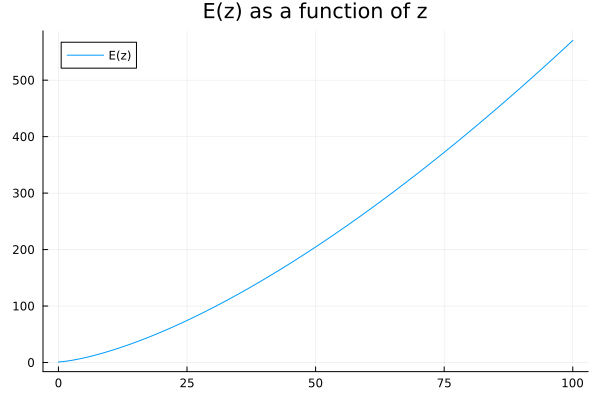

In [41]:
plot(z_b, E_z, label="E(z)", title = "E(z) as a function of z")

In [42]:
chi_computed = Blast.compute_χ.(z_b, Ref(cosmo))

1024-element Vector{Float64}:
     0.0
   425.39092929785244
   829.8260094795561
  1213.014772627897
  1575.1395874330933
  1916.752530625164
  2238.6715450897973
  2541.8876938477338
  2827.489047109736
  3096.602254420029
  3350.3502476901394
  3589.823366845252
  3816.0609682171066
     ⋮
 12841.70345001777
 12842.479208790124
 12843.25383117724
 12844.027319950843
 12844.799677873174
 12845.570907697096
 12846.34101216607
 12847.109994014247
 12847.87785596647
 12848.644600738344
 12849.410231036256
 12850.174749557433

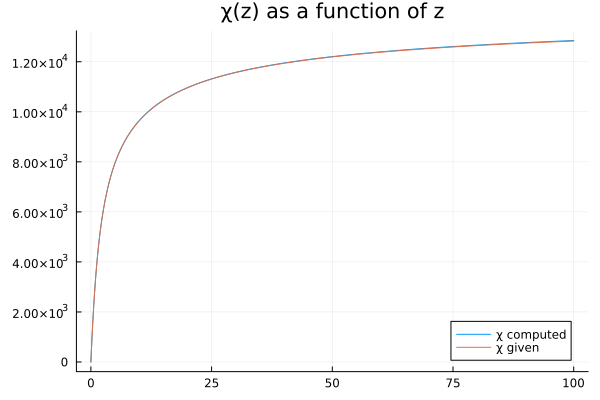

In [48]:
plot(z_b, chi_computed, label="χ computed", title = "chi(z) as a function of z")
plot!(z_b, χ_b, label="χ given", title = "χ(z) as a function of z")